# Tableshift


In [ ]:
from pathlib import Path

Path.cwd()

WindowsPath('c:/Users/jeffr/GitHub/tesis-darl/code/notebooks')

In [6]:
def find_project_root(start=Path.cwd()):
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists() and (path / "data").exists():
            return path
    raise RuntimeError("No se encontro la raiz del repo")


PROJECT_ROOT = find_project_root()
CACHE_DIR = PROJECT_ROOT / "data" / "raw" / "tableshift_cache"

print(f"Project root: {PROJECT_ROOT}" f"\nCache dir: {CACHE_DIR}")

Project root: c:\Users\jeffr\GitHub\tesis-darl
Cache dir: c:\Users\jeffr\GitHub\tesis-darl\data\raw\tableshift_cache


In [8]:
from tableshift import get_dataset
from tableshift.core.features import PreprocessorConfig

c:\Users\jeffr\GitHub\tesis-darl\.venv\Lib\site-packages\xport\__about__.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [10]:
def passthrough_preprocessor() -> PreprocessorConfig:
    """Return a PreprocessorConfig that skips all TableShift transformations."""
    return PreprocessorConfig(
        categorical_features="passthrough",
        numeric_features="passthrough",
        dropna="all",
    )

In [11]:
name = "diabetes_readmission"  # Hospital readmission — OOD splits by admission source

dset = get_dataset(
    name,
    cache_dir=str(CACHE_DIR),
    preprocessor_config=passthrough_preprocessor(),
)

c:\Users\jeffr\GitHub\tesis-darl\.venv\Lib\site-packages\sklearn\compose\_column_transformer.py:1590: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  df_row = df_row.select_dtypes(
c:\Users\jeffr\GitHub\tesis-darl\.venv\Lib\site-packages\sklearn\compose\_column_transformer.py:1590: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  df_row = df_row.select_dtypes(


In [12]:
print(dset)

TabularDataset(name='diabetes_readmission', preprocessor_config=PreprocessorConfig(categorical_features='passthrough', numeric_features='passthrough', domain_labels='label_encode', passthrough_columns=None, dropna='all', use_extended_names=False, map_targets=False, cast_targets_to_default_type=False, min_frequency=None, max_categories=None, n_bins=5, sub_illegal_chars=True), config=DatasetConfig(cache_dir='c:\\Users\\jeffr\\GitHub\\tesis-darl\\data\\raw\\tableshift_cache', download=True, random_seed=948324), initialize_data=True, splitter=DomainSplitter(val_size=0.1, random_state=264738, id_test_size=0.1, domain_split_varname='admission_source_id', domain_split_ood_values=[7], domain_split_id_values=None, domain_split_gt_thresh=None, drop_domain_split_col=True, ood_val_size=0.1), grouper=Grouper(features_and_values={'race': ['Caucasian'], 'gender': ['Male']}, drop=False, transformer=None), feature_names=['chlorpropamide', 'miglitol', 'metformin-rosiglitazone', 'diag_2', 'acetohexamide'

In [21]:
X_train, y_train, g_train, _ = dset.get_pandas(split="train")
X_val, y_val, g_val, _ = dset.get_pandas(split="validation")
X_id_test, y_id_test, g_id_test, _ = dset.get_pandas(split="id_test")
X_ood, y_ood, g_ood, _ = dset.get_pandas(split="ood_test")

print(
    f"X_train:    {X_train.shape} | y_train: {y_train.shape} | g_train: {g_train.shape}"
)
print(f"X_val:      {X_val.shape} | y_val: {y_val.shape} | g_val: {g_val.shape}")
print(
    f"X_id_test:  {X_id_test.shape} | y_id_test: {y_id_test.shape} | g_id_test: {g_id_test.shape}"
)
print(f"X_ood: {X_ood.shape} | y_ood: {y_ood.shape} | g_ood: {g_ood.shape}")

X_train:    (34288, 46) | y_train: (34288,) | g_train: (34288, 2)
X_val:      (4286, 46) | y_val: (4286,) | g_val: (4286, 2)
X_id_test:  (4287, 46) | y_id_test: (4287,) | g_id_test: (4287, 2)
X_ood: (50968, 46) | y_ood: (50968,) | g_ood: (50968, 2)


In [23]:
y_train.value_counts()

readmitted
0.0    19742
1.0    14546
Name: count, dtype: int64

In [70]:
cols = X_train.columns.tolist()

for col in cols:
    print(f"{col}")

race
gender
age
weight
admission_type_id
discharge_disposition_id
time_in_hospital
payer_code
medical_specialty
num_lab_procedures
num_procedures
num_medications
number_outpatient
number_emergency
number_inpatient
diag_1
diag_2
diag_3
number_diagnoses
max_glu_serum
A1Cresult
metformin
repaglinide
nateglinide
chlorpropamide
glimepiride
acetohexamide
glipizide
glyburide
tolbutamide
pioglitazone
rosiglitazone
acarbose
miglitol
troglitazone
tolazamide
examide
citoglipton
insulin
glyburide-metformin
glipizide-metformin
glimepiride-pioglitazone
metformin-rosiglitazone
metformin-pioglitazone
change
diabetesMed


In [14]:
int_cols = X_train.select_dtypes(include="number")
vars = sorted(int_cols.columns.tolist())

for var in vars:
    print(f"{var}")

admission_type_id
discharge_disposition_id
gender
num_lab_procedures
num_medications
num_procedures
number_diagnoses
number_emergency
number_inpatient
number_outpatient
race
time_in_hospital


In [15]:
CARDINALITY_THRESHOLD = 20  # numeric cols with <= this many unique values → ordinal

int_cols = X_train.select_dtypes(include="number").columns.tolist()

continuous = [c for c in int_cols if X_train[c].nunique() > CARDINALITY_THRESHOLD]
ordinal = [c for c in int_cols if X_train[c].nunique() <= CARDINALITY_THRESHOLD]

print(f"Continuous ({len(continuous)}): {continuous}")
print(f"Ordinal    ({len(ordinal)}):    {ordinal}")

Continuous (4): ['discharge_disposition_id', 'num_lab_procedures', 'num_medications', 'number_outpatient']
Ordinal    (8):    ['race', 'gender', 'admission_type_id', 'time_in_hospital', 'num_procedures', 'number_emergency', 'number_inpatient', 'number_diagnoses']


# Drift Injection


In [16]:
# Covariate shift: how many standard deviations to shift the features
SEVERITY_COVARIATE = {"low": 0.5, "medium": 1.5, "high": 3.0}

# Concept drift: probability of flipping each label (capped at 45%)
SEVERITY_CONCEPT = {"low": 0.08, "medium": 0.25, "high": 0.45}

SEED = 42

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Literal, Optional, Tuple


class DriftInjector:
    """
    Injects synthetic drift into a dataset split.

    Parameters
    ----------
    drift_type : "covariate" | "concept" | "both"
    severity   : "low" | "medium" | "high"
    start_idx  : row index at which drift begins
    duration   : None = permanent; int = temporary spike of that many rows
    random_state : RNG seed
    """

    def __init__(
        self,
        drift_type: Literal["covariate", "concept", "both"],
        severity: Literal["low", "medium", "high"],
        start_idx: int = 0,
        duration: Optional[int] = None,
        random_state: int = SEED,
    ):
        if drift_type not in ("covariate", "concept", "both"):
            raise ValueError(
                f"drift_type must be 'covariate', 'concept', or 'both'; got '{drift_type}'"
            )
        if severity not in SEVERITY_COVARIATE:
            raise ValueError(
                f"severity must be 'low', 'medium', or 'high'; got '{severity}'"
            )

        self.drift_type = drift_type
        self.severity = severity
        self.start_idx = start_idx
        self.duration = duration
        self.random_state = random_state

        self._covariate_multiplier = SEVERITY_COVARIATE[severity]
        self._flip_prob = SEVERITY_CONCEPT[severity]
        self._num_features: list = []
        self._feature_stds: Optional[dict] = None

    def fit(self, X_ref: pd.DataFrame, num_features: list) -> "DriftInjector":
        """Compute per-feature stds from the reference split."""
        self._num_features = [c for c in num_features if c in X_ref.columns]
        self._feature_stds = {
            col: float(X_ref[col].std()) for col in self._num_features
        }
        return self

    def inject(self, X: pd.DataFrame, y: pd.Series) -> Tuple[pd.DataFrame, pd.Series]:
        """Apply drift to rows [start_idx : start_idx + duration]."""
        if self._feature_stds is None:
            raise RuntimeError("Call fit() with reference data before inject().")

        rng = np.random.default_rng(self.random_state)
        X_out = X.copy()
        y_out = y.copy()

        end_idx = (
            min(self.start_idx + self.duration, len(X))
            if self.duration is not None
            else len(X)
        )
        affected = np.zeros(len(X), dtype=bool)
        affected[self.start_idx : end_idx] = True

        if self.drift_type in ("covariate", "both"):
            for col in self._num_features:
                shift = self._covariate_multiplier * self._feature_stds[col]
                X_out[col] = X_out[col].astype(float)
                X_out.loc[affected, col] = X_out.loc[affected, col] + shift

        if self.drift_type in ("concept", "both"):
            n_affected = int(affected.sum())
            flip_flags = rng.random(n_affected) < self._flip_prob
            flip_idxs = np.where(affected)[0][flip_flags]
            y_arr = y_out.values.copy()
            y_arr[flip_idxs] = 1 - y_arr[flip_idxs]
            y_out = pd.Series(y_arr, index=y_out.index, name=y_out.name)

        return X_out, y_out

## Covariate Shift


Visualizing features: ['discharge_disposition_id', 'num_lab_procedures', 'num_medications', 'number_outpatient']


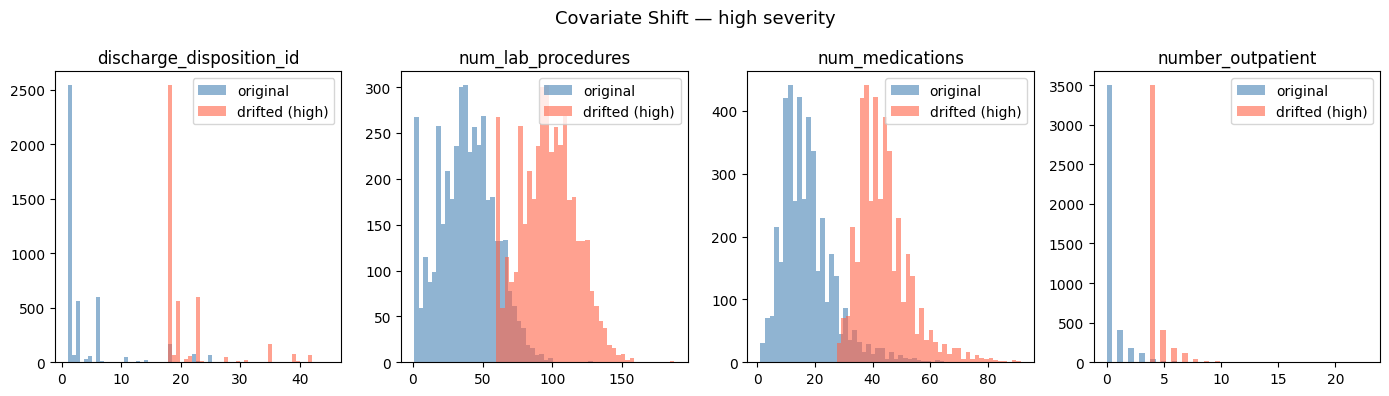

In [18]:
VIZ_FEATURES = continuous[:]
print("Visualizing features:", VIZ_FEATURES)

injector_cov = DriftInjector(drift_type="covariate", severity="high", start_idx=0)
injector_cov.fit(X_train, continuous)
X_cov, _ = injector_cov.inject(X_id_test, y_id_test)

fig, axes = plt.subplots(1, len(VIZ_FEATURES), figsize=(14, 4))
for ax, col in zip(axes, VIZ_FEATURES):
    ax.hist(
        X_id_test[col].dropna(), bins=40, alpha=0.6, label="original", color="steelblue"
    )
    ax.hist(
        X_cov[col].dropna(), bins=40, alpha=0.6, label="drifted (high)", color="tomato"
    )
    ax.set_title(col)
    ax.legend()
plt.suptitle("Covariate Shift — high severity", fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
# Compare mean shift across all severity levels for the first feature
col = continuous[0]
orig_mean = X_train[col].mean()
print(f"Feature: {col}  (original mean: {orig_mean:.4f})")

for sev in ["low", "medium", "high"]:
    inj = DriftInjector(drift_type="covariate", severity=sev)
    inj.fit(X_train, continuous)
    X_d, _ = inj.inject(X_id_test, y_id_test)
    drift_mean = X_d[col].mean()
    print(
        f"  {sev:8s} drift mean: {drift_mean:.4f}  (shift = {drift_mean - orig_mean:+.4f})"
    )

Feature: discharge_disposition_id  (original mean: 3.9082)
  low      drift mean: 6.6226  (shift = +2.7144)
  medium   drift mean: 12.2289  (shift = +8.3207)
  high     drift mean: 20.6384  (shift = +16.7302)


## Concept Drift


In [ ]:
orig_rate = y_id_test.mean()
print(f"Original positive label rate: {orig_rate:.4f}")

for sev in ["low", "medium", "high"]:
    inj = DriftInjector(drift_type="concept", severity=sev)
    inj.fit(X_train, continuous)
    _, y_d = inj.inject(X_id_test, y_id_test)
    drifted_rate = y_d.mean()
    n_flipped = (y_d != y_id_test).sum()
    print(
        f"  {sev:8s} — positive rate: {drifted_rate:.4f}  |  labels flipped: {n_flipped}/{len(y_d)}"
    )

Original positive label rate: 0.4161
  low      — positive rate: 0.4311  |  labels flipped: 330/4287
  medium   — positive rate: 0.4549  |  labels flipped: 1096/4287
  high     — positive rate: 0.4903  |  labels flipped: 1940/4287


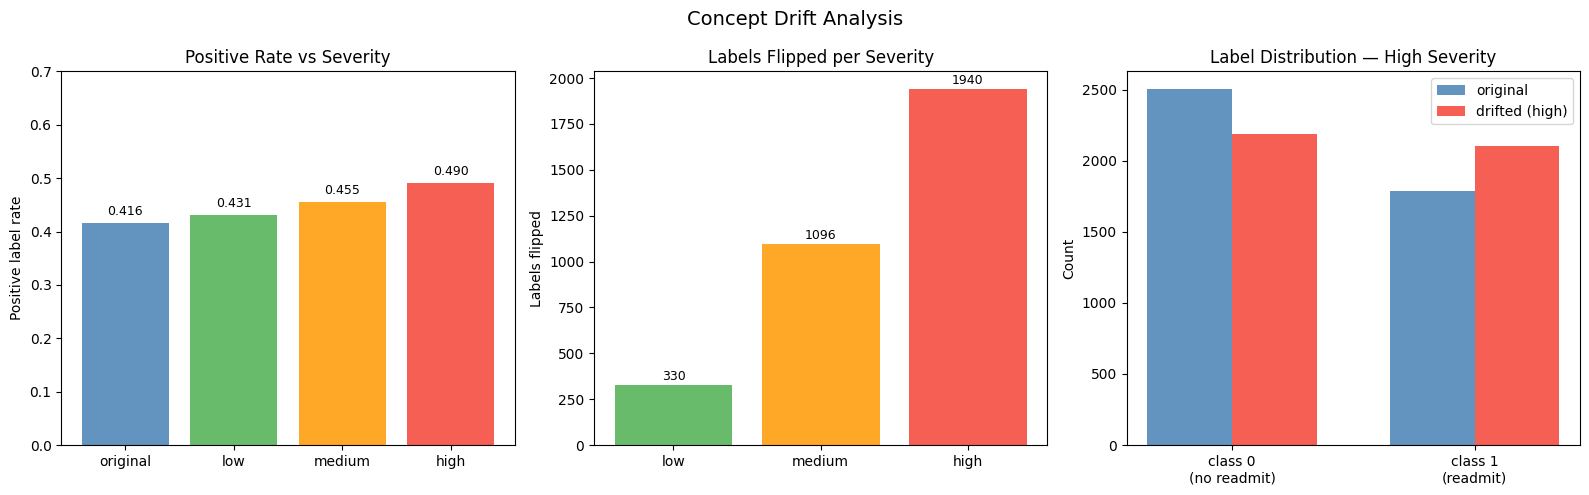

In [20]:
severities = ["low", "medium", "high"]
flip_probs = [0.08, 0.25, 0.45]
colors = ["#4caf50", "#ff9800", "#f44336"]

drifted_labels = {}
for sev in severities:
    inj = DriftInjector(drift_type="concept", severity=sev)
    inj.fit(X_train, continuous)
    _, y_d = inj.inject(X_id_test, y_id_test)
    drifted_labels[sev] = y_d

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: positive label rate per severity
ax = axes[0]
rates = [y_id_test.mean()] + [drifted_labels[s].mean() for s in severities]
labels = ["original"] + severities
bar_colors = ["steelblue"] + colors
bars = ax.bar(labels, rates, color=bar_colors, alpha=0.85)
ax.set_ylim(0, 0.7)
ax.set_ylabel("Positive label rate")
ax.set_title("Positive Rate vs Severity")
for bar, rate in zip(bars, rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{rate:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

# Plot 2: number of flipped labels per severity
ax = axes[1]
n_flipped = [(drifted_labels[s] != y_id_test).sum() for s in severities]
ax.bar(severities, n_flipped, color=colors, alpha=0.85)
ax.set_ylabel("Labels flipped")
ax.set_title("Labels Flipped per Severity")
for i, (sev, n) in enumerate(zip(severities, n_flipped)):
    ax.text(i, n + 10, str(n), ha="center", va="bottom", fontsize=9)

# Plot 3: label distribution before/after for high severity
ax = axes[2]
orig_counts = y_id_test.value_counts().sort_index()
high_counts = drifted_labels["high"].value_counts().sort_index()
x = [0, 1]
width = 0.35
ax.bar(
    [i - width / 2 for i in x],
    orig_counts.values,
    width,
    label="original",
    color="steelblue",
    alpha=0.85,
)
ax.bar(
    [i + width / 2 for i in x],
    high_counts.values,
    width,
    label="drifted (high)",
    color="#f44336",
    alpha=0.85,
)
ax.set_xticks(x)
ax.set_xticklabels(["class 0\n(no readmit)", "class 1\n(readmit)"])
ax.set_ylabel("Count")
ax.set_title("Label Distribution — High Severity")
ax.legend()

plt.suptitle("Concept Drift Analysis", fontsize=14)
plt.tight_layout()
plt.show()

# Models


In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from xgboost import XGBClassifier

In [53]:
estimator = XGBClassifier(enable_categorical=True, tree_method="hist")
estimator.fit(X_train, y_train)

for split_name, X, y in [("id_test", X_id_test, y_id_test), ("ood_test", X_ood, y_ood)]:
    preds = estimator.predict(X)
    proba = estimator.predict_proba(X)[:, 1]
    acc = accuracy_score(y, preds)
    auc = roc_auc_score(y, proba)
    f1 = f1_score(y, preds)
    print(
        f"[{split_name}]  accuracy: {acc:.3f}  |  AUC-ROC: {auc:.3f}  |  F1: {f1:.3f}"
    )

[id_test]  accuracy: 0.642  |  AUC-ROC: 0.661  |  F1: 0.533
[ood_test]  accuracy: 0.596  |  AUC-ROC: 0.640  |  F1: 0.552


## Metrics

| Metric                         | Description                                       | Use case                                                      |
| ------------------------------ | ------------------------------------------------- | ------------------------------------------------------------- |
| **Accuracy**                   | % of correct predictions                          | Baseline sanity check                                         |
| **AUC-ROC**                    | Area under ROC curve — ranks positive vs negative | Main metric: threshold-independent, handles class imbalance   |
| **F1-score**                   | Harmonic mean of precision and recall             | Good for imbalanced datasets like readmission (~41% positive) |
| **Δ AUC (id_test → ood_test)** | Performance drop under real OOD shift             | Measures natural distribution shift impact                    |
| **Δ AUC (clean → drifted)**    | Performance drop after drift injection            | Measures synthetic drift impact                               |


In [58]:
cat_cols = X_train.select_dtypes(include="category").columns.tolist()
num_cols = X_train.select_dtypes(include="number").columns.tolist()

preprocessor = ColumnTransformer(
    [
        (
            "cat",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
            cat_cols,
        ),
        ("num", StandardScaler(), num_cols),
    ]
)

lr_pipeline = Pipeline(
    [
        ("prep", preprocessor),
        ("clf", LogisticRegression(max_iter=1000, solver="saga", n_jobs=-1)),
    ]
)

lr_pipeline.fit(X_train, y_train)

for split_name, X, y in [("id_test", X_id_test, y_id_test), ("ood_test", X_ood, y_ood)]:
    preds = lr_pipeline.predict(X)
    proba = lr_pipeline.predict_proba(X)[:, 1]
    acc = accuracy_score(y, preds)
    auc = roc_auc_score(y, proba)
    f1 = f1_score(y, preds)
    print(
        f"[{split_name}]  accuracy: {acc:.3f}  |  AUC-ROC: {auc:.3f}  |  F1: {f1:.3f}"
    )

c:\Users\jeffr\GitHub\pfc1\.venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[id_test]  accuracy: 0.638  |  AUC-ROC: 0.661  |  F1: 0.436
[ood_test]  accuracy: 0.591  |  AUC-ROC: 0.643  |  F1: 0.449
